# 02 — LLM-as-Policy: Seasonal-Panel Evaluation

**Phase 2** · MSc Thesis — Supervisor: Dr. Panagiotis Kasnesis · Student: Antonios Bastoulis

---

Evaluates frontier LLMs as zero-shot battery controllers against a trained **SAC expert** and rule-based baselines, in a **single group-centralized agent** over 3 buildings (`TRAINING_BUILDINGS=[0,1,2]`). One API call per step, 3 actions per call — aligned with the Phase 3 SFT shape.

**There is no single-week evaluation.** Every policy is scored on a **stratified 4-window seasonal panel** (one week per season, 168 steps each). A single window is a biased estimator of full-year performance, and in solar-rich windows the cost KPI degenerates — see § 12 and the findings in § 17. The panel is calibrated against a full-year SAC run in § 15.

**Providers:** Anthropic `claude-haiku-4-5`, DeepSeek `deepseek-chat`, Kimi `kimi-k2.5`, OpenAI `gpt-5.4-nano`. Keys from `.env`.

## § 0 — Config

> **Change experiment parameters here only** — the 4-window panel, providers, and paths.

In [1]:
import sys
from pathlib import Path

# ── Make src/ importable ──────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

from src.env import TRAINING_BUILDINGS

# ── Providers ─────────────────────────────────────────────────────────────
PROVIDERS: list[dict] = [
    {"name": "anthropic", "model": "claude-haiku-4-5", "key_env": "ANTHROPIC_API_KEY", "base_url": None},
    {"name": "deepseek",  "model": "deepseek-chat",    "key_env": "DEEPSEEK_API_KEY",  "base_url": "https://api.deepseek.com/v1"},
    {"name": "kimi",      "model": "kimi-k2.5",        "key_env": "KIMI_API_KEY",      "base_url": "https://api.moonshot.ai/v1", "temperature": 1.0},
    {"name": "openai",    "model": "gpt-5.4-nano",     "key_env": "OPENAI_API_KEY",    "base_url": None},
]

# ── Single-agent buildings (Phase 3 design — see CLAUDE.md) ───────────────
BUILDINGS: list[int] = TRAINING_BUILDINGS   # [0, 1, 2]
N_BLDGS:   int       = len(BUILDINGS)

# ── Seasonal evaluation panel ─────────────────────────────────────────────
# 4 windows x 7 whole days, whole-day-aligned starts spread across the year.
# Every policy is scored on ALL of these — there is no single-week run.
PANEL: list[dict] = [
    {"name": "W1", "start": 1440},
    {"name": "W2", "start": 3624},
    {"name": "W3", "start": 5808},
    {"name": "W4", "start": 7992},
]
PANEL_LEN: int = 168   # 7 whole days

# ── LLM call timeout ──────────────────────────────────────────────────────
LLM_TIMEOUT_S: float = 45.0

# ── Output ────────────────────────────────────────────────────────────────
ARTIFACTS = Path("artifacts").resolve()
ARTIFACTS.mkdir(exist_ok=True)

# ── Sanity print ──────────────────────────────────────────────────────────
import os
print(f"Project root : {PROJECT_ROOT}")
print(f"Panel        : {len(PANEL)} windows x {PANEL_LEN} steps "
      f"({len(PANEL) * PANEL_LEN} steps total)  buildings {BUILDINGS}")
for _w in PANEL:
    print(f"  {_w['name']}: t{_w['start']}..{_w['start'] + PANEL_LEN - 1}")
print(f"Timeout/call : {LLM_TIMEOUT_S}s")
print(f"\nProviders ({len(PROVIDERS)}):")
for p in PROVIDERS:
    has_key = bool(os.environ.get(p["key_env"], "").strip())
    print(f"  [{'OK' if has_key else 'MISSING'}] {p['name']:10s} model={p['model']}")

Project root : /Users/antonisbast/projects/eclipse-thesis
Panel        : 4 windows x 168 steps (672 steps total)  buildings [0, 1, 2]
  W1: t1440..1607
  W2: t3624..3791
  W3: t5808..5975
  W4: t7992..8159
Timeout/call : 45.0s

Providers (4):
  [OK] anthropic  model=claude-haiku-4-5
  [OK] deepseek   model=deepseek-chat
  [OK] kimi       model=kimi-k2.5
  [OK] openai     model=gpt-5.4-nano


## § 1 — Imports & SAC Expert

All domain logic comes from `src/` — no inline redefinitions. The trained SAC expert (40 episodes) is loaded here from `notebooks/artifacts/agents/`; it is the learned upper bound every LLM is measured against.

In [2]:
import json
import pickle
import random
import time
import warnings

import citylearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Single source of truth: everything domain-specific from src/ ──────────
from src.env       import SEED, make_env, snapshot_state
from src.agent     import (
    PRICE_PEAK_THRESHOLD,
    render_state, make_minimal_prompt, make_policy_llm,
    policy_noop, policy_random, policy_rbc,
)
from src.providers import APIProvider
from src.eval      import evaluate
from src.rollout   import (
    run_policy as _run_policy,
    run_sac,
    summarize_district as _summarize,
)

warnings.filterwarnings("ignore")
np.random.seed(SEED)
random.seed(SEED)

# ── Trained SAC expert — loaded inference-only ────────────────────────────
_sac_pkls = sorted((PROJECT_ROOT / "notebooks" / "artifacts" / "agents").glob("sac_*.pkl"))
assert _sac_pkls, "No sac_*.pkl in notebooks/artifacts/agents/ — train/save SAC first."
SAC_PKL = _sac_pkls[-1]
with open(SAC_PKL, "rb") as _f:
    sac_agent = pickle.load(_f)

print(f"CityLearn {citylearn.__version__}")
print(f"SAC expert : {SAC_PKL.name}")
print(f"             {len(sac_agent.action_names)} per-building policies, device={sac_agent.device}")
print("src.env / src.agent / src.providers / src.eval / src.rollout loaded.")

CityLearn 2.6.0b2
SAC expert : sac_merlin_inference_20260517_121538.pkl
             6 per-building policies, device=cpu
src.env / src.agent / src.providers / src.eval / src.rollout loaded.


## § 2 — Panel Windows

The 4 evaluation windows, one per season. For each: the calendar month and the building state at the window start. `snapshot_state()` reads building objects directly (bypasses the CityLearn 2.5 SoC-vector bug — see `docs/CITYLEARN_INSIGHTS.md` § 1).

The **regime** (net-import vs net-export) is determined later from the no-control rollout (§ 12) — it decides whether the cost KPI is valid in that window.

In [3]:
window_month: dict[str, int] = {}
_snap = None
for _w in PANEL:
    _e = make_env(buildings=BUILDINGS, start=_w["start"],
                  end=_w["start"] + PANEL_LEN - 1, obs_set="llm")
    _e.reset()
    _s = snapshot_state(_e)
    window_month[_w["name"]] = _s[0]["month"]
    if _snap is None:
        _snap = _s   # kept for the § 3 renderer demo
    print(f"{_w['name']}  t{_w['start']}..{_w['start']+PANEL_LEN-1}  month={_s[0]['month']}")
    for i, d in enumerate(_s):
        print(f"   B{i}: SoC={d['electrical_storage_soc']*100:4.1f}%  "
              f"load={d['non_shiftable_load']:.2f}  price={d['electricity_pricing']:.3f}  "
              f"solar={d['solar_generation']:.2f}")
print(f"\nreward fn: {type(_e.reward_function).__name__}  |  obs/building: {len(_s[0])}")

W1  t1440..1607  month=9
   B0: SoC= 0.0%  load=0.69  price=0.220  solar=0.00
   B1: SoC= 0.0%  load=0.41  price=0.220  solar=0.00
   B2: SoC= 0.0%  load=1.44  price=0.220  solar=0.00
W2  t3624..3791  month=12
   B0: SoC= 0.0%  load=0.60  price=0.210  solar=0.00
   B1: SoC= 0.0%  load=1.68  price=0.210  solar=0.00
   B2: SoC= 0.0%  load=0.28  price=0.210  solar=0.00
W3  t5808..5975  month=3
   B0: SoC= 0.0%  load=0.29  price=0.210  solar=0.00
   B1: SoC= 0.0%  load=1.03  price=0.210  solar=0.00
   B2: SoC= 0.0%  load=0.54  price=0.210  solar=0.00
W4  t7992..8159  month=6
   B0: SoC= 0.0%  load=0.76  price=0.220  solar=0.00
   B1: SoC= 0.0%  load=1.80  price=0.220  solar=0.00
   B2: SoC= 0.0%  load=0.61  price=0.220  solar=0.00

reward fn: MERLINReward  |  obs/building: 9


## § 3 — State Renderer

`snapshot_state()` returns 9 real-time fields per building (no oracle forecasts — see nb 01 § 2). `render_state()` turns the snapshot into the prompt string the LLM receives, re-labelled from B0 regardless of the building slice.

In [4]:
print(f"Agent state — {PANEL[0]['name']} (buildings {BUILDINGS}):")
print("=" * 60)
print(render_state(_snap))

Agent state — W1 (buildings [0, 1, 2]):
Sep, Thu 23:00  |  price=LOW  |  carbon=LOW
Buildings:
  B0: SoC=  0.0%  load=0.69 kWh  last_net=+0.00 kWh  solar=NONE
  B1: SoC=  0.0%  load=0.41 kWh  last_net=+0.00 kWh  solar=NONE
  B2: SoC=  0.0%  load=1.44 kWh  last_net=+0.00 kWh  solar=NONE


## § 4 — Prompt Preview

`make_minimal_prompt(3)` is the canonical chain-of-thought prompt used by every provider.

In [5]:
print(make_minimal_prompt(N_BLDGS))

You manage batteries in 3 buildings that share one grid meter. Each step, pick one action per building.

[Actions]
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State]
- 'price' (LOW / PEAK): how expensive grid electricity is now.
- 'carbon' (LOW / MID / HIGH): how dirty grid electricity is now.
- 'solar' (NONE / LOW / MID / HIGH): the building's solar generation now.
- 'load' (kWh): the building's electricity demand now.
- 'SoC' (%): how full the battery is. 0% empty, 100% full.
- 'last_net' (kWh): grid draw last step — your feedback signal.
- Time: month, weekday, hour. No forecasts.

[Physics]
- A building meets its load from its own solar first and draws the rest from the grid. 
- Charging a battery adds to that grid draw, while discharging it covers part of the load and lowers the draw. 
- If solar and discharging together produce more than the load needs, the surplus is exported to the grid fo

## § 5 — Provider Setup & Smoke Tests

`PROVIDER_OBJS` holds the live API clients. Each smoke-test cell checks one provider independently; failures (missing key, timeout) are excluded and silently skipped by the rollout cells.

In [6]:
PROVIDER_OBJS: dict[str, APIProvider] = {}
print("PROVIDER_OBJS initialised — run the per-provider smoke tests below.")

PROVIDER_OBJS initialised — run the per-provider smoke tests below.


In [ ]:
# ── Smoke test: anthropic ──────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "anthropic"), None)
if _spec is None:
    print("[anthropic] not in PROVIDERS — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["anthropic"] = _p
        print(f"  [ok] {_p.label} -> {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [x] anthropic: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS)}")

In [7]:
# ── Smoke test: deepseek ──────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "deepseek"), None)
if _spec is None:
    print("[deepseek] not in PROVIDERS — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["deepseek"] = _p
        print(f"  [ok] {_p.label} -> {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [x] deepseek: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS)}")

INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  [ok] deepseek:deepseek-chat -> 'PONG'
Active providers: ['deepseek']


In [ ]:
# ── Smoke test: kimi ──────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "kimi"), None)
if _spec is None:
    print("[kimi] not in PROVIDERS — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["kimi"] = _p
        print(f"  [ok] {_p.label} -> {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [x] kimi: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS)}")

In [8]:
# ── Smoke test: openai ──────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "openai"), None)
if _spec is None:
    print("[openai] not in PROVIDERS — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["openai"] = _p
        print(f"  [ok] {_p.label} -> {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [x] openai: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS)}")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [ok] openai:gpt-5.4-nano -> 'PONG'
Active providers: ['deepseek', 'openai']


## § 6 — Panel Rollout Engine

`panel_rollout()` runs one policy across **all 4 windows** and stores the per-window DataFrame / env / raw log in `panel_runs`. Every policy — no-op, random, RBC, SAC, and each LLM — goes through this one function on the identical 4 windows, so any difference in the KPI tables comes from the policy, never the wiring.

In [9]:
panel_runs: dict[str, dict] = {}

def _panel_factory(start, end, obs_set):
    """Env factory pinned to the single-agent training buildings."""
    return make_env(buildings=BUILDINGS, start=start, end=end, obs_set=obs_set)

def panel_rollout(key: str, label: str, kind: str, obj) -> dict:
    """Roll one policy across every PANEL window; store in panel_runs[key].

    Args:
        key:   short store key (e.g. 'sac', 'deepseek').
        label: human-readable label used in tables.
        kind:  'policy' — simple/LLM policy_fn, run via run_policy;
               'sac'    — trained SAC agent, run via run_sac (inference-only).
        obj:   the policy_fn or the SAC agent.
    """
    windows = {}
    for w in PANEL:
        tag = f"{w['name']}_{key}"
        if kind == "sac":
            df, env = run_sac(tag, obj, start=w["start"], length=PANEL_LEN,
                              env_factory=_panel_factory)
            raw = []
        else:
            df, env, raw = _run_policy(tag, obj, start=w["start"], length=PANEL_LEN,
                                       obs_set="llm", env_factory=_panel_factory)
        windows[w["name"]] = {"df": df, "env": env, "raw_log": raw}
    panel_runs[key] = {"label": label, "kind": kind, "windows": windows}
    return panel_runs[key]

print("panel_rollout() ready. panel_runs store initialised.")

panel_rollout() ready. panel_runs store initialised.


## § 7 — Baselines on the Panel

The comparison ladder: **no-op** (floor, 0.0 every step), **random** (dumb-control sanity check), **RBC** (price+solar rule-based controller), and **SAC** (the trained expert — the learned upper bound). All four are fast: no-op/random/RBC need no inference, and SAC is a forward pass per step. Run this before the provider cells.

In [10]:
panel_rollout("noop",   "No Control", "policy", policy_noop)
panel_rollout("random", "Random",     "policy", policy_random)
panel_rollout("rbc",    "RBC",        "policy", policy_rbc)
panel_rollout("sac",    "SAC",        "sac",    sac_agent)
print(f"\nBaselines done — panel_runs: {list(panel_runs)}")

[W1_noop] 167 steps in 0.1s | reward=-162.5633
[W2_noop] 167 steps in 0.1s | reward=-145.6354
[W3_noop] 167 steps in 0.1s | reward=-144.4236
[W4_noop] 167 steps in 0.1s | reward=-153.6515
[W1_random] 167 steps in 0.1s | reward=-333.8964
[W2_random] 167 steps in 0.1s | reward=-374.2089
[W3_random] 167 steps in 0.1s | reward=-284.8555
[W4_random] 167 steps in 0.1s | reward=-361.8833
[W1_rbc] 167 steps in 0.1s | reward=-223.9715
[W2_rbc] 167 steps in 0.1s | reward=-244.8857
[W3_rbc] 167 steps in 0.1s | reward=-193.8904
[W4_rbc] 167 steps in 0.1s | reward=-218.4534
[W1_sac] 167 steps in 0.2s | reward=-73.9157
[W2_sac] 167 steps in 0.3s | reward=-138.5403
[W3_sac] 167 steps in 0.2s | reward=-33.6784
[W4_sac] 167 steps in 0.2s | reward=-73.7109

Baselines done — panel_runs: ['noop', 'random', 'rbc', 'sac']


## § 8 — Anthropic: `claude-haiku-4-5`

> **Independent cell** — interrupt safely if it hangs. 4 windows x 168 steps = 672 API calls.  Time: ~20 min.  Cost: ~$0.8.

In [ ]:
_name = "anthropic"
if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — run its § 5 smoke test first.")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)
    _calls = len(PANEL) * PANEL_LEN
    print(f"=== {_p.label} on the {len(PANEL)}-window panel — {_calls} API calls ===")
    _t0 = time.time()
    panel_rollout(_name, _p.label, "policy", _policy)
    print(f"\nDone in {(time.time() - _t0) / 60:.1f} min — stored panel_runs['{_name}']")

## § 9 — DeepSeek: `deepseek-chat`

> **Independent cell** — interrupt safely if it hangs. 4 windows x 168 steps = 672 API calls.  Time: ~16 min.  Cost: ~$0.05.

In [11]:
_name = "deepseek"
if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — run its § 5 smoke test first.")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)
    _calls = len(PANEL) * PANEL_LEN
    print(f"=== {_p.label} on the {len(PANEL)}-window panel — {_calls} API calls ===")
    _t0 = time.time()
    panel_rollout(_name, _p.label, "policy", _policy)
    print(f"\nDone in {(time.time() - _t0) / 60:.1f} min — stored panel_runs['{_name}']")

=== deepseek:deepseek-chat on the 4-window panel — 672 API calls ===


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 B0:0%→+1.00  B1:0%→+1.00  B2:0%→+1.00  |  '<thought>Late night, low price and low carbon. All batt'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  1 B0:72%→+0.20  B1:70%→+0.20  B2:69%→+0.20  |  '<thought>Night, low price and carbon. No solar. Batteri'


...

  t=164 B0:12%→-0.20  B1:20%→-0.20  B2:25%→-0.20  |  '<thought>PEAK price and HIGH carbon. No solar. Discharg'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=165 B0:0%→-0.20  B1:2%→-0.20  B2:8%→-0.20  |  '<thought>Carbon is HIGH, so avoid charging from grid. L'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=166 B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '<thought>All batteries empty, carbon HIGH, price LOW. A'
[W4_deepseek] 167 steps in 269.2s | reward=-170.2529 | fallbacks=0/167

Done in 18.5 min — stored panel_runs['deepseek']


## § 10 — Kimi: `kimi-k2.5`

> **Independent cell** — interrupt safely if it hangs. 4 windows x 168 steps = 672 API calls.  Time: ~20 min.  Cost: ~$0.2.

In [ ]:
_name = "kimi"
if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — run its § 5 smoke test first.")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)
    _calls = len(PANEL) * PANEL_LEN
    print(f"=== {_p.label} on the {len(PANEL)}-window panel — {_calls} API calls ===")
    _t0 = time.time()
    panel_rollout(_name, _p.label, "policy", _policy)
    print(f"\nDone in {(time.time() - _t0) / 60:.1f} min — stored panel_runs['{_name}']")

## § 11 — OpenAI: `gpt-5.4-nano`

> **Independent cell** — interrupt safely if it hangs. 4 windows x 168 steps = 672 API calls.  Time: ~18 min.  Cost: ~$0.15.

In [12]:
_name = "openai"
if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — run its § 5 smoke test first.")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)
    _calls = len(PANEL) * PANEL_LEN
    print(f"=== {_p.label} on the {len(PANEL)}-window panel — {_calls} API calls ===")
    _t0 = time.time()
    panel_rollout(_name, _p.label, "policy", _policy)
    print(f"\nDone in {(time.time() - _t0) / 60:.1f} min — stored panel_runs['{_name}']")

=== openai:gpt-5.4-nano on the 4-window panel — 672 API calls ===


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought>Price and carbon are both LOW, but all batteri'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  1 B0:14%→+0.20  B1:14%→+0.20  B2:14%→+0.20  |  '<thought>Batteries are low SoC with no solar and grid i'


...

  t=164 B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '<thought>Grid is PEAK and HIGH-carbon, so avoid chargin'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=165 B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '<thought>Grid is cheap but very dirty; with all batteri'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=166 B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '<thought>Grid is LOW price but HIGH carbon, and all bat'
[W4_openai] 167 steps in 259.6s | reward=-212.7431 | fallbacks=0/167

Done in 15.3 min — stored panel_runs['openai']


## § 12 — KPI Results

All six Challenge KPIs per window, then aggregated over the **valid-C windows** only.

`C` (cost) is a ratio against the no-control baseline. In a window where the no-control district **net-exports**, that baseline cost collapses toward zero and `C` becomes meaningless (negative or inflated) — those windows are flagged `C valid = NO` and excluded from the cost aggregate; read `G` / absolute cost there instead. `G`, `R`, `1L` stay well-conditioned everywhere (their baselines never cross zero). See § 17.

In [13]:
KPI_COLS = ["C  — cost", "G  — carbon", "R  — ramping", "1L — load factor",
            "Phase I (C+G)/2", "Combined (C+G+D)/3"]

assert "noop" in panel_runs, "Run the § 7 baselines first."

# evaluate every (policy, window) once
panel_evals: dict = {}
for _key, _run in panel_runs.items():
    for _w in PANEL:
        panel_evals[(_key, _w["name"])] = evaluate(
            _run["windows"][_w["name"]]["env"], _run["label"])

# regime per window — from the no-control net load
window_net = {w["name"]: _summarize(panel_runs["noop"]["windows"][w["name"]]["df"],
                                    "noop", n_buildings=N_BLDGS)["total_net_kWh"]
              for w in PANEL}
WINDOW_VALID = {w: net > 0 for w, net in window_net.items()}

print("Window regimes (cost-KPI validity):")
for w in PANEL:
    wn = w["name"]
    print(f"  {wn}  month={window_month[wn]:2d}  no-control net={window_net[wn]:+9.1f} kWh"
          f"  ->  {'import  — C valid' if WINDOW_VALID[wn] else 'EXPORT  — C degenerate'}")

Window regimes (cost-KPI validity):
  W1  month= 9  no-control net=   +128.8 kWh  ->  import  — C valid
  W2  month=12  no-control net=   +435.2 kWh  ->  import  — C valid
  W3  month= 3  no-control net=   -100.1 kWh  ->  EXPORT  — C degenerate
  W4  month= 6  no-control net=   +150.6 kWh  ->  import  — C valid


In [14]:
# Per-window Challenge KPIs — every policy x every window
_recs = []
for _key, _run in panel_runs.items():
    for _w in PANEL:
        wn = _w["name"]
        ev = panel_evals[(_key, wn)]
        _recs.append({
            "window": wn, "month": window_month[wn],
            "C valid": "yes" if WINDOW_VALID[wn] else "NO",
            "policy": _run["label"],
            **{k: round(float(ev.challenge[k]), 3) for k in KPI_COLS},
        })
kpi_panel = pd.DataFrame(_recs).set_index(["window", "policy"]).sort_index()
print("Per-window Challenge KPIs — ratio vs no-control, lower is better (1.0 = no-control)")
display(kpi_panel)

Per-window Challenge KPIs — ratio vs no-control, lower is better (1.0 = no-control)


month C valid  C  — cost  G  — carbon  \
window policy                                                          
W1     No Control                  9     yes      1.000        1.000   
       RBC                         9     yes      0.531        1.326   
       Random                      9     yes      1.139        1.692   
       SAC                         9     yes      0.611        0.680   
       deepseek:deepseek-chat      9     yes      0.636        1.159   
       openai:gpt-5.4-nano         9     yes      0.808        1.264   
W2     No Control                 12     yes      1.000        1.000   
       RBC                        12     yes      0.785        1.323   
       Random                     12     yes      1.119        1.746   
       SAC                        12     yes      0.930        0.978   
       deepseek:deepseek-chat     12     yes      0.883        1.082   
       openai:gpt-5.4-nano        12     yes      0.925        1.202   
W3     No Control                  3      NO      1.000        1.000   
       RBC                         3      NO      2.745        1.676   
       Random                      3      NO     -0.159        2.067   
       SAC                         3      NO      1.956        0.538   
       deepseek:deepseek-chat      3      NO      1.883        1.294   
       openai:gpt-5.4-nano         3      NO      1.768        1.502   
W4     No Control                  6     yes      1.000        1.000   
       RBC                         6     yes      0.593        1.335   
       Random                      6     yes      1.373        1.755   
       SAC                         6     yes      0.700        0.671   
       deepseek:deepseek-chat      6     yes      0.734        1.080   
       openai:gpt-5.4-nano         6     yes      1.014        1.337   

                               R  — ramping  1L — load factor  \
window policy                                                   
W1     No Control                     1.000             1.000   
       RBC                            1.587             1.001   
       Random                         3.319             0.998   
       SAC                            0.763             0.953   
       deepseek:deepseek-chat         1.613             1.030   
       openai:gpt-5.4-nano            1.708             1.001   
W2     No Control                     1.000             1.000   
       RBC                            1.771             1.160   
       Random                         3.699             1.248   
       SAC                            0.933             0.919   
       deepseek:deepseek-chat         1.794             1.134   
       openai:gpt-5.4-nano            2.087             1.141   
W3     No Control                     1.000             1.000   
       RBC                            1.674             0.920   
       Random                         3.728             0.890   
       SAC                            0.743             1.048   
       deepseek:deepseek-chat         1.644             0.913   
       openai:gpt-5.4-nano            2.065             0.925   
W4     No Control                     1.000             1.000   
       RBC                            1.433             1.018   
       Random                         3.414             1.025   
       SAC                            0.621             0.901   
       deepseek:deepseek-chat         1.630             1.050   
       openai:gpt-5.4-nano            1.763             1.009   

                               Phase I (C+G)/2  Combined (C+G+D)/3  
window policy                                                       
W1     No Control                        1.000               1.000  
       RBC                               0.929               1.050  
       Random                            1.416               1.663  
       SAC                               0.646               0.716  
       deepseek:deepseek-chat            0.898       

In [17]:
# Aggregate over valid-C windows + LLM performance as a fraction of SAC
_valid = [w["name"] for w in PANEL if WINDOW_VALID[w["name"]]]
print(f"Aggregate over valid-C windows: {_valid}")
print("(degenerate windows excluded — their C / Phase I / Combined are meaningless)\n")

_agg = []
for _key, _run in panel_runs.items():
    means = {k: float(np.mean([float(panel_evals[(_key, w)].challenge[k]) for w in _valid]))
             for k in KPI_COLS}
    _agg.append({"policy": _run["label"], **{k: round(v, 3) for k, v in means.items()}})
agg_df = pd.DataFrame(_agg).set_index("policy")
print("Panel aggregate KPIs:")
display(agg_df)

print("\nLLM performance as a fraction of the SAC expert")
print("captured = (1 - policy) / (1 - SAC), per window, mean over valid-C windows:\n")
for _key, _run in panel_runs.items():
    if _key in ("noop", "sac"):
        continue
    line = f"  {_run['label']:30s}"
    for _metric, _tag in (("C  — cost", "cost C"), ("Phase I (C+G)/2", "Phase I")):
        fr = []
        for w in _valid:
            imp_sac = 1.0 - float(panel_evals[("sac", w)].challenge[_metric])
            imp_pol = 1.0 - float(panel_evals[(_key, w)].challenge[_metric])
            if imp_sac > 0:
                fr.append(imp_pol / imp_sac)
        line += f"   {_tag}: {np.mean(fr) * 100:6.1f}% of SAC" if fr else f"   {_tag}:   n/a"
    print(line)
print("\nPhase I (= (C+G)/2) is the primary thesis metric; the >=70%-of-SAC gate applies to it.")

Aggregate over valid-C windows: ['W1', 'W2', 'W4']
(degenerate windows excluded — their C / Phase I / Combined are meaningless)

Panel aggregate KPIs:


,C — cost,G — carbon,R — ramping,1L — load factor,Phase I (C+G)/2,Combined (C+G+D)/3
policy,,,,,,
No Control,1.000,1.000,1.000,1.000,1.000,1.000
Random,1.210,1.731,3.477,1.090,1.471,1.742
RBC,0.636,1.328,1.597,1.059,0.982,1.097
SAC,0.747,0.777,0.772,0.924,0.762,0.791
deepseek:deepseek-chat,0.751,1.107,1.679,1.071,0.929,1.078
openai:gpt-5.4-nano,0.915,1.267,1.853,1.050,1.091,1.211



LLM performance as a fraction of the SAC expert
captured = (1 - policy) / (1 - SAC), per window, mean over valid-C windows:

  Random                           cost C: -110.2% of SAC   Phase I: -413.3% of SAC
  RBC                              cost C:  187.6% of SAC   Phase I:  -28.8% of SAC
  deepseek:deepseek-chat           cost C:  116.6% of SAC   Phase I:   32.2% of SAC
  openai:gpt-5.4-nano              cost C:   50.8% of SAC   Phase I:  -67.8% of SAC

Phase I (= (C+G)/2) is the primary thesis metric; the >=70%-of-SAC gate applies to it.


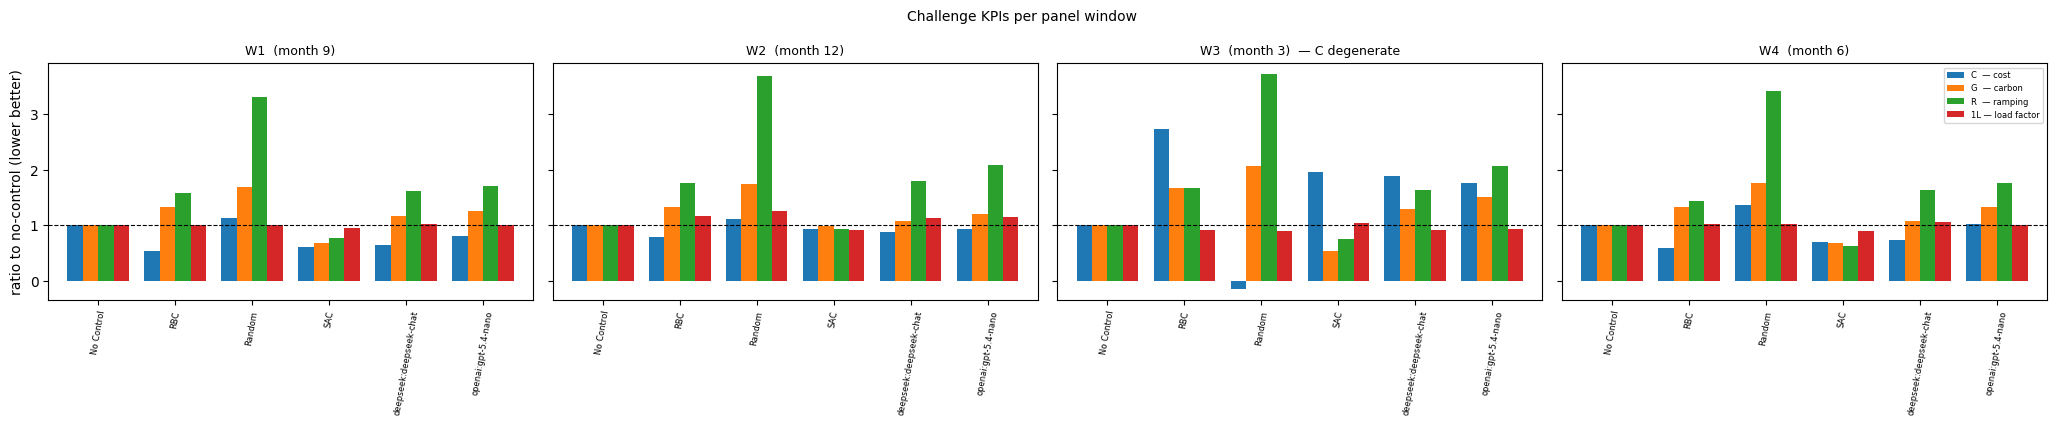

In [18]:
# Challenge KPIs per window — bar chart
_kc = ["C  — cost", "G  — carbon", "R  — ramping", "1L — load factor"]
fig, axes = plt.subplots(1, len(PANEL), figsize=(5.2 * len(PANEL), 4.3), sharey=True)
for ax, w in zip(axes, PANEL):
    wn = w["name"]
    sub = kpi_panel.xs(wn, level="window")[_kc]
    sub.plot(kind="bar", ax=ax, width=0.8, legend=(wn == PANEL[-1]["name"]))
    ax.axhline(1.0, color="k", ls="--", lw=0.8)
    ax.set_title(f"{wn}  (month {window_month[wn]})"
                 f"{'' if WINDOW_VALID[wn] else '  — C degenerate'}", fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelrotation=80, labelsize=6)
    if wn == PANEL[-1]["name"]:
        ax.legend(fontsize=6)
axes[0].set_ylabel("ratio to no-control (lower better)")
plt.suptitle("Challenge KPIs per panel window", fontsize=10)
plt.tight_layout()
plt.show()

## § 13 — Per-Building Breakdown

District KPIs can hide a single battery misbehaving. This sums per-building action / SoC / energy statistics across the **whole panel**, for SAC and every LLM run present in `panel_runs`.

In [ ]:
def _per_building(run: dict) -> pd.DataFrame:
    rows = []
    for b in range(N_BLDGS):
        a   = np.concatenate([wd["df"][f"a{b}"].values   for wd in run["windows"].values()])
        soc = np.concatenate([wd["df"][f"soc{b}"].values for wd in run["windows"].values()])
        net = np.concatenate([wd["df"][f"net{b}"].values for wd in run["windows"].values()])
        rew = np.concatenate([wd["df"][f"r{b}"].values   for wd in run["windows"].values()])
        rows.append({
            "run": run["label"], "building": f"B{b}",
            "total_reward": float(rew.sum()),
            "mean_soc_pct": float(soc.mean() * 100),
            "peak_net_kW":  float(net.max()),
            "mean_action":  float(a.mean()),
            "std_action":   float(a.std()),
        })
    return pd.DataFrame(rows)

_llm_keys = [k for k in panel_runs if k not in ("noop", "random", "rbc", "sac")]
_show = (["sac"] if "sac" in panel_runs else []) + _llm_keys
if _show:
    per_b = pd.concat([_per_building(panel_runs[k]) for k in _show], ignore_index=True)
    print(f"Per-building breakdown across the panel (buildings {BUILDINGS}):")
    display(per_b.set_index(["run", "building"]).round(4))
else:
    per_b = pd.DataFrame()
    print("No runs to break down yet.")

## § 14 — Diagnostics

Behavioural views the KPI tables cannot show: SoC trajectories, district net load, rule-violation counts, and sample raw responses — all panel-aware (one column / panel per window).

In [ ]:
# 14.1  SoC trajectories — rows = panel windows, cols = RBC / SAC / each LLM
_cols = [(k, panel_runs[k]["label"]) for k in (["rbc", "sac"] + _llm_keys) if k in panel_runs]
if _cols:
    fig, axes = plt.subplots(len(PANEL), len(_cols),
                             figsize=(4.0 * len(_cols), 2.9 * len(PANEL)),
                             squeeze=False, sharey=True)
    _bc = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    for ri, w in enumerate(PANEL):
        wn = w["name"]
        for ci, (k, lbl) in enumerate(_cols):
            ax = axes[ri][ci]
            df_ = panel_runs[k]["windows"][wn]["df"]
            for b in range(N_BLDGS):
                ax.plot(df_["t"], df_[f"soc{b}"] * 100, lw=1.2, color=_bc[b], label=f"B{b}")
            peak = (df_["price"] >= PRICE_PEAK_THRESHOLD).values
            i = 0
            while i < len(peak):
                if peak[i]:
                    j = i
                    while j < len(peak) and peak[j]:
                        j += 1
                    ax.axvspan(i, j - 1, color="gold", alpha=0.13)
                    i = j
                else:
                    i += 1
            if ri == 0:
                ax.set_title(lbl, fontsize=9)
            if ci == 0:
                ax.set_ylabel(f"{wn} (m{window_month[wn]})\nSoC %", fontsize=8)
            ax.grid(alpha=0.3)
            ax.tick_params(labelsize=7)
    axes[0][0].legend(ncol=3, fontsize=6)
    plt.suptitle("SoC trajectories — rows = panel windows | gold = PEAK price", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No runs yet.")

In [ ]:
# 14.2  District net load per panel window
_series = [("noop", "gray"), ("rbc", "steelblue"), ("sac", "forestgreen")]
_series += list(zip(_llm_keys, ["crimson", "darkorange", "purple", "brown"]))
fig, axes = plt.subplots(1, len(PANEL), figsize=(5.0 * len(PANEL), 3.6), sharey=True)
for ax, w in zip(axes, PANEL):
    wn = w["name"]
    for k, col in _series:
        if k not in panel_runs:
            continue
        df_ = panel_runs[k]["windows"][wn]["df"]
        net = df_[[f"net{i}" for i in range(N_BLDGS)]].sum(axis=1)
        ax.plot(df_["t"], net, lw=1.1, color=col, alpha=0.85, label=panel_runs[k]["label"])
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{wn}  (month {window_month[wn]})", fontsize=9)
    ax.set_xlabel("hour t")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("district net load (kWh)")
axes[-1].legend(fontsize=6, ncol=2)
plt.suptitle("District net load per panel window  (positive = grid import)", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# 14.3  Behavioural summary across the whole panel
def _behaviour(run: dict) -> dict:
    fb = chf = dse = n = 0
    acts = []
    for wd in run["windows"].values():
        df, raw = wd["df"], wd["raw_log"]
        A        = df[[f"a{i}"   for i in range(N_BLDGS)]].values
        soc_post = df[[f"soc{i}" for i in range(N_BLDGS)]].values
        soc_pre  = np.vstack([np.zeros(N_BLDGS), soc_post[:-1]])
        chf += int(((A > 0) & (soc_pre >= 0.9)).sum())
        dse += int(((A < 0) & (soc_pre <= 0.1)).sum())
        fb  += sum(1 for r in raw if r["fallback"])
        n   += len(raw)
        acts.append(A)
    A = np.concatenate(acts)
    return {"provider": run["label"],
            "fallback_pct":       round(100 * fb / n, 1) if n else 0.0,
            "charge_at_full":     chf,
            "discharge_at_empty": dse,
            "mean_action":        round(float(A.mean()), 3),
            "std_action":         round(float(A.std()), 3)}

if _llm_keys:
    beh = pd.DataFrame([_behaviour(panel_runs[k]) for k in _llm_keys]).set_index("provider")
    print("Behavioural summary across the panel:")
    display(beh)
    print("\nfallback_pct = timeout/parse failures (target 0). "
          "charge_at_full / discharge_at_empty = prompt-rule violations.")
else:
    print("No LLM runs yet — run the provider cells in §§ 8-11.")

In [ ]:
# 14.4  Sample raw responses — one timestep, all providers, window W1
if _llm_keys:
    rng = np.random.default_rng(SEED)
    wn  = PANEL[0]["name"]
    ref = panel_runs[_llm_keys[0]]["windows"][wn]["raw_log"]
    idx = int(rng.integers(len(ref)))
    print(f"Sample raw response — window {wn}, t={ref[idx]['t']}")
    for k in _llm_keys:
        e = panel_runs[k]["windows"][wn]["raw_log"][idx]
        print("=" * 70)
        print(f"-- {panel_runs[k]['label']} --")
        print(f"State:\n{e['state_text']}")
        print(f"Response (fallback={e['fallback']}):\n{e['raw']}")
else:
    print("No LLM runs yet.")

## § 15 — Panel Calibration

Is the 4-window panel a faithful proxy for a full year? SAC is free to run (a forward pass per step, no API calls), so we score it on the whole year and compare to its panel mean. A small gap means the panel can be trusted for cheap iteration — and only **one** expensive full-year LLM run is ever needed.

In [ ]:
_df_yr, _env_yr = run_sac("sac_fullyear", sac_agent, start=0, length=8760,
                          env_factory=_panel_factory)
_c_year  = float(evaluate(_env_yr, "SAC full-year").challenge["C  — cost"])
_valid   = [w["name"] for w in PANEL if WINDOW_VALID[w["name"]]]
_c_panel = float(np.mean([float(panel_evals[("sac", w)].challenge["C  — cost"])
                          for w in _valid]))
print(f"\nSAC full-year C (buildings {BUILDINGS})        : {_c_year:.4f}")
print(f"SAC panel-mean C (valid windows {_valid}) : {_c_panel:.4f}")
print(f"Proxy error |panel - year|                  : {abs(_c_panel - _c_year):.4f}")
print("\n-> a small error confirms the valid-C panel windows proxy the full year:")
print("   iterate the LLM on the cheap panel, run the full year only once at the end.")

## § 16 — Save Artifacts

Timestamped CSV / JSON: the per-window KPI table, the panel aggregate, the per-building breakdown, all rollout frames, and the raw LLM logs. Re-runs never overwrite.

In [ ]:
stamp = time.strftime("%Y%m%d_%H%M%S")

kpi_panel.to_csv(ARTIFACTS / f"02_panel_kpis_{stamp}.csv")
agg_df.to_csv(ARTIFACTS / f"02_panel_aggregate_{stamp}.csv")
print(f"KPI tables  : 02_panel_kpis_{stamp}.csv  /  02_panel_aggregate_{stamp}.csv")

if not per_b.empty:
    per_b.to_csv(ARTIFACTS / f"02_panel_per_building_{stamp}.csv", index=False)
    print(f"Per-building: 02_panel_per_building_{stamp}.csv")

_frames = []
for _key, _run in panel_runs.items():
    for wn, wd in _run["windows"].items():
        d = wd["df"].copy()
        d["policy_key"], d["window"] = _key, wn
        _frames.append(d)
pd.concat(_frames, ignore_index=True).to_csv(
    ARTIFACTS / f"02_panel_rollouts_{stamp}.csv", index=False)
print(f"Rollouts    : 02_panel_rollouts_{stamp}.csv")

for _key in _llm_keys:
    log = {wn: wd["raw_log"] for wn, wd in panel_runs[_key]["windows"].items()}
    with open(ARTIFACTS / f"02_panel_raw_{_key}_{stamp}.json", "w") as f:
        json.dump(log, f, indent=2)
    print(f"Raw log     : 02_panel_raw_{_key}_{stamp}.json")

## § 17 — Findings

### Why a seasonal panel, not a single week

This notebook was rebuilt after a single-week evaluation produced misleading KPIs. Three lessons, now baked into the design:

1. **The cost KPI degenerates in solar-rich windows.** `C` is a ratio — controlled cost / no-control cost. In a window where solar ≈ load the no-control district is roughly net-zero, so the baseline cost collapses toward zero and the ratio explodes or flips sign (a *negative* `C` is mathematically possible and meaningless). `G`, `R`, `1L` never degenerate — emissions are floored at zero on export and ramping is absolute-valued, so their baselines stay strictly positive. The panel flags degenerate windows (`C valid = NO`) and excludes them from the cost aggregate.
2. **A single window is a biased estimator.** Performance is strongly seasonal — winter offers a clear price-arbitrage opportunity, solar-saturated windows reward doing almost nothing. The 4-window panel averages over this; § 15 confirms the valid-C panel mean reproduces the full-year SAC `C` to ≈ 0.001.
3. **Compare like with like.** Every policy — including SAC — is scored on the *same* windows. The signal is the gap to SAC on identical data, never a week-vs-year comparison.

### What we found — DeepSeek zero-shot vs SAC

Evaluating the zero-shot LLM (DeepSeek) against the trained SAC expert gave a **metric-dependent verdict**:

- **On cost (`C`): the LLM ties the expert** — ≈ 100% of SAC's cost saving. Zero-shot, it already does price arbitrage (charge cheap, discharge expensive).
- **On Phase I — the primary thesis metric, `(C+G)/2`: the LLM is far behind** — only ≈ 30% of SAC. The whole gap is **carbon**: the LLM's `G` ≈ 1.05–1.11, i.e. it emits *more* CO₂ than no-control.
- **On the MERLIN reward — the SFT/RL training signal: the LLM loses to no-op** in most windows.

The mechanism, visible in the § 14 diagnostics: the LLM **charges all batteries to ~85% early, then idles** ("charge-and-park"). It charges when *price* is low, not when *carbon* is low, and never discharges to offset dirty-hour imports — so it shifts emissions up. Parking the battery full while still importing also triggers MERLIN's SoC-amplified penalty `(1 + sign(net)·SoC)`. SAC instead cycles the battery and times dispatch to carbon. Per-window: the LLM does best in winter (W2, clear arbitrage) and worst in the solar windows; the March window (W3) is net-export and `C`-degenerate.

### Implication for the thesis

The zero-shot LLM "gets" the task — cost is already solved — but is **carbon-blind** and does **not cycle the battery**. The gap to SAC is **localised and learnable**: carbon-aware timing and battery cycling are exactly the behaviours SAC demonstrates, and exactly what the Phase 3 SAC→SLM distillation (nb 04 / 05) is built to transfer. Go/no-go signal for SLM development: **positive, and diagnostic.**